[db] Connected to database: Hydat.sqlite3
HYDAT VERSION: [['1.0', '2026-04-17 08:16:30.000']]
[regime] Mixed class n=308  (aseasonal R<0.15: 298; Sep/Oct peak: 10)

SED_SAMPLES by type:
SED_DATA_TYPE
DI    84302
PI     7775
SV       35
Name: count, dtype: int64

Rating curves: 271 stations (significant: 253)
Seasonal phase: 329 stations; closed loop: 183

Within-station pre/post pairs: 1
Stations with D50: 380
[psd] flow percentile of PSD samples: median=65.2 (50 = no bias), n=15,817, Wilcoxon p=0

==> Analysis subset: 271 | primary (significant fits): 253
[regime] classified: 223 | unclassified: 30
reason
incomplete annual cycle (<10 months)    24
fewer than 5 years of monthly flow       4
no monthly-flow record                   2

[class composition]
                  regime   n  median_area_km2  n_area_gt_50000  n_cordillera_BC_YT  n_prairie_boreal_AB_SK_MB  n_ontario  n_regulated  median_runoff_mm_yr
Glacial / high-elevation  17          14340.0                4                   

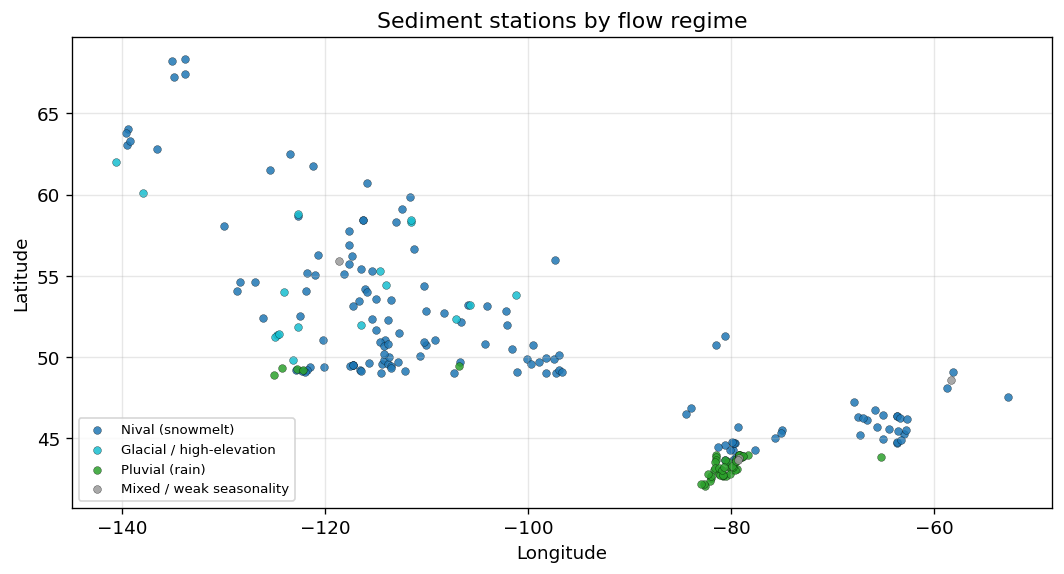

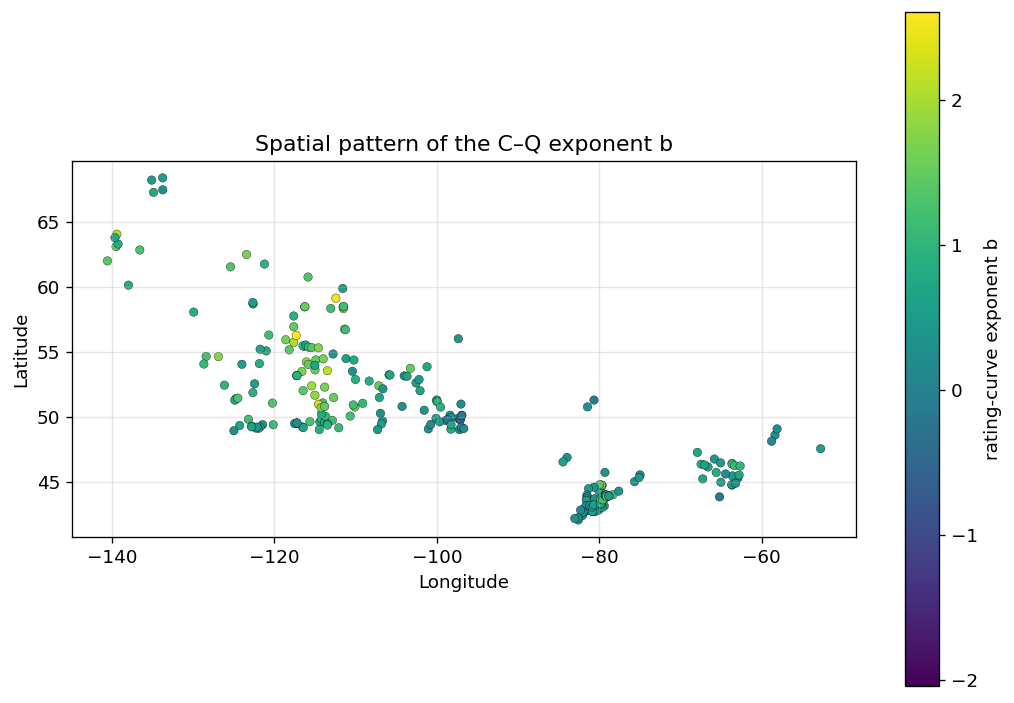

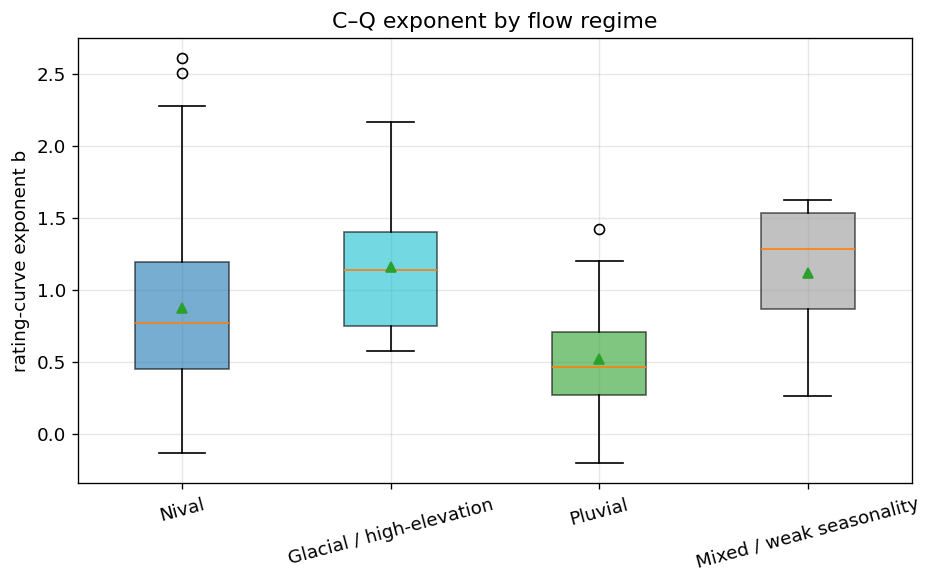

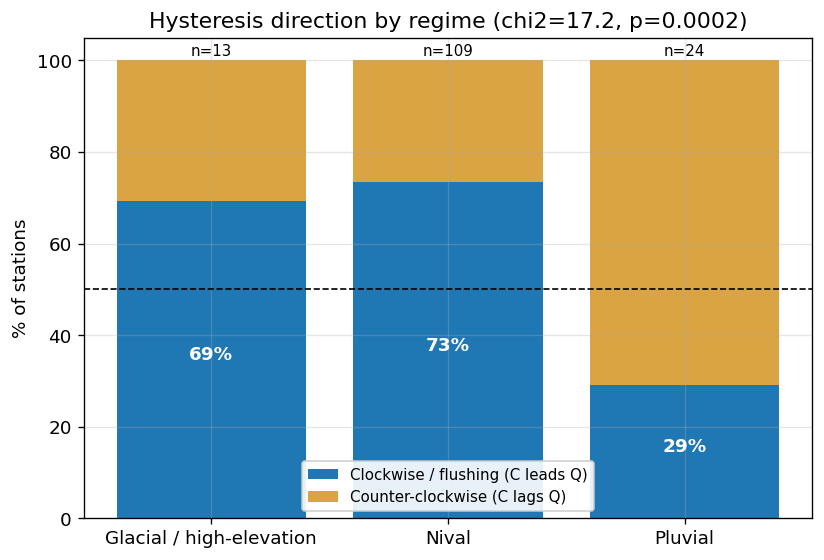

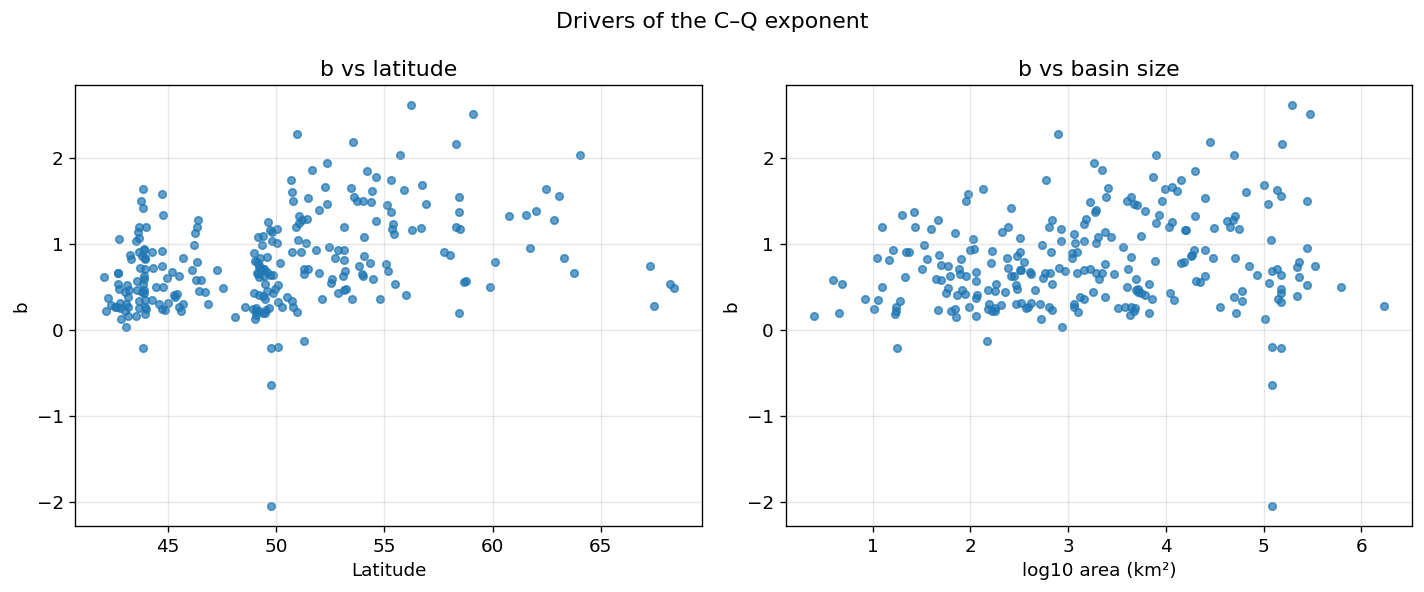


[fig06 exemplars]
  Nival (snowmelt)           05AA023  OLDMAN RIVER NEAR WALDRON'S CORNER         AB  area=1448.00 km2  regulated=0  phase=-0.57 (clockwise)
  Pluvial (rain)             02GA032  O.A.C. FARM GAUGE NO. 5 AT GUELPH          ON  area=2.51 km2  regulated=0  phase=+1.66 (counter-clockwise)
  Glacial / high-elevation   10CD001  MUSKWA RIVER NEAR FORT NELSON              BC  area=20250.00 km2  regulated=0  phase=-0.78 (clockwise)


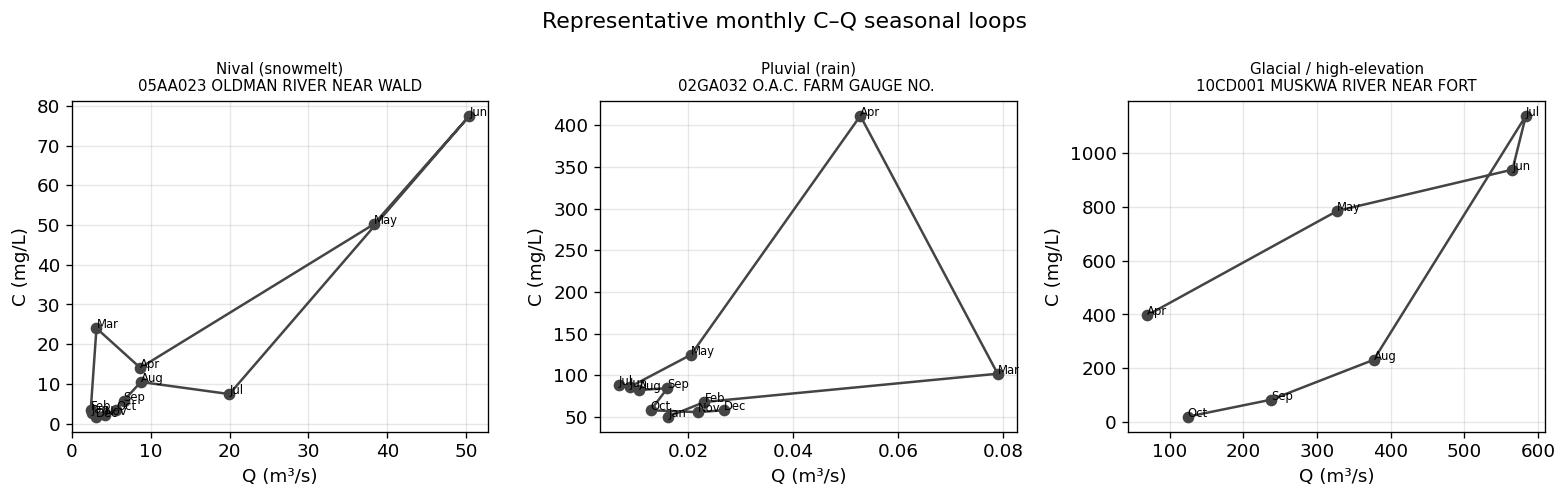

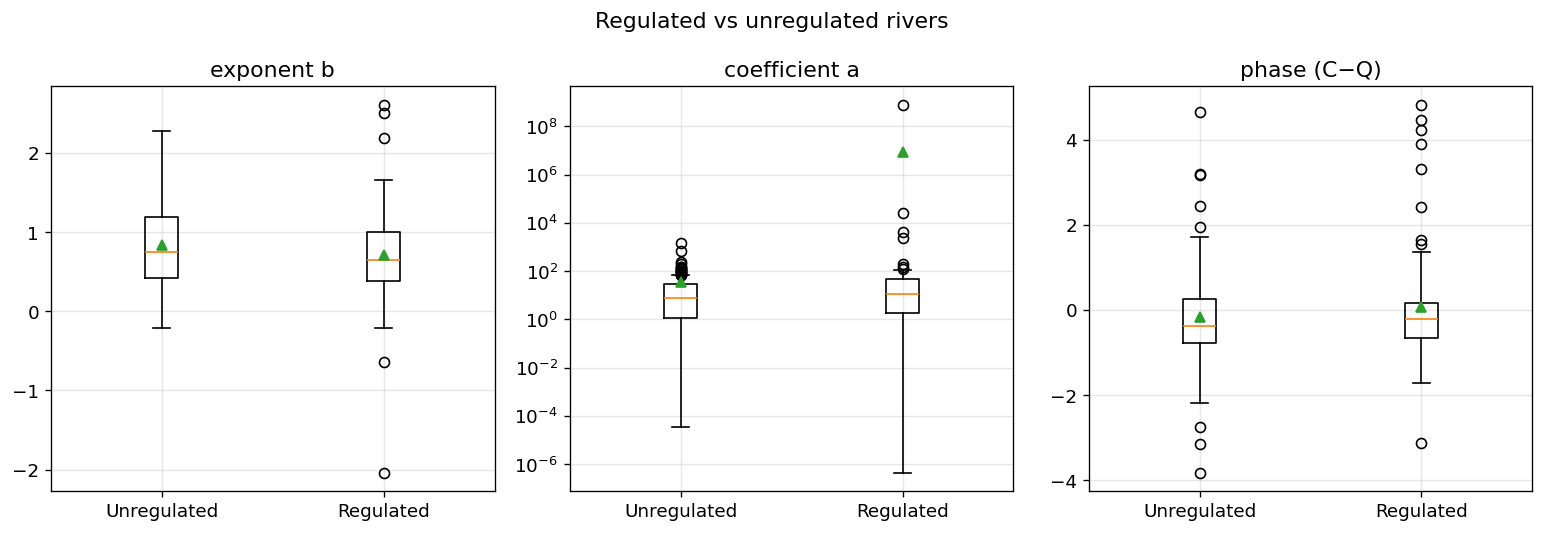

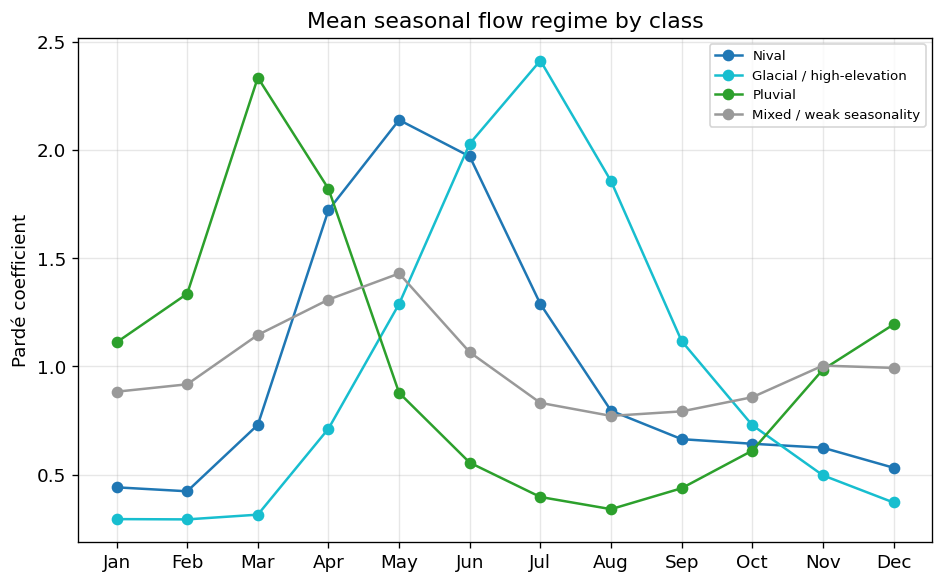

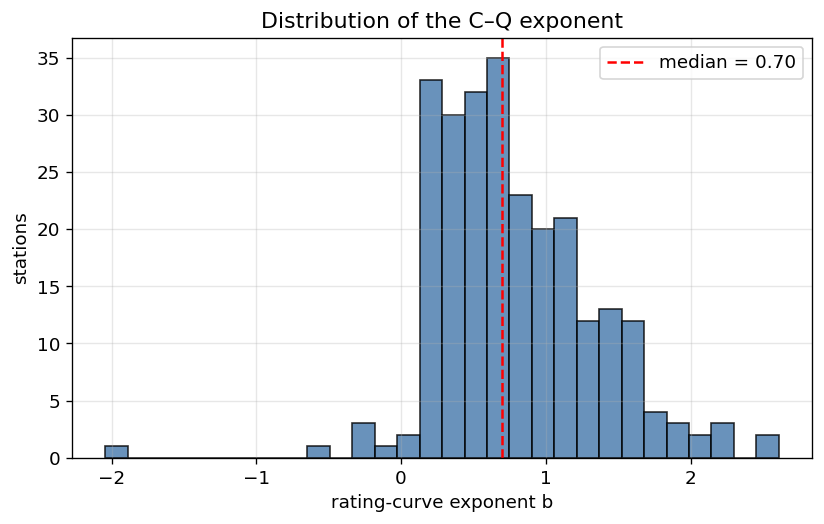

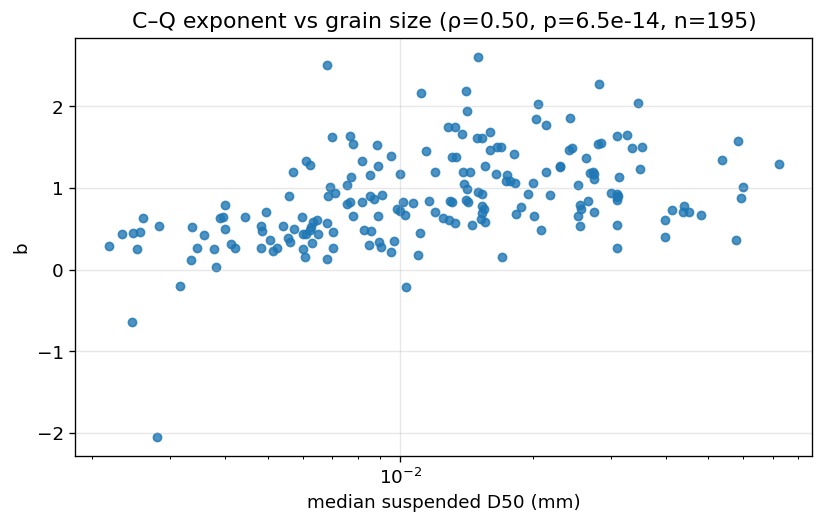

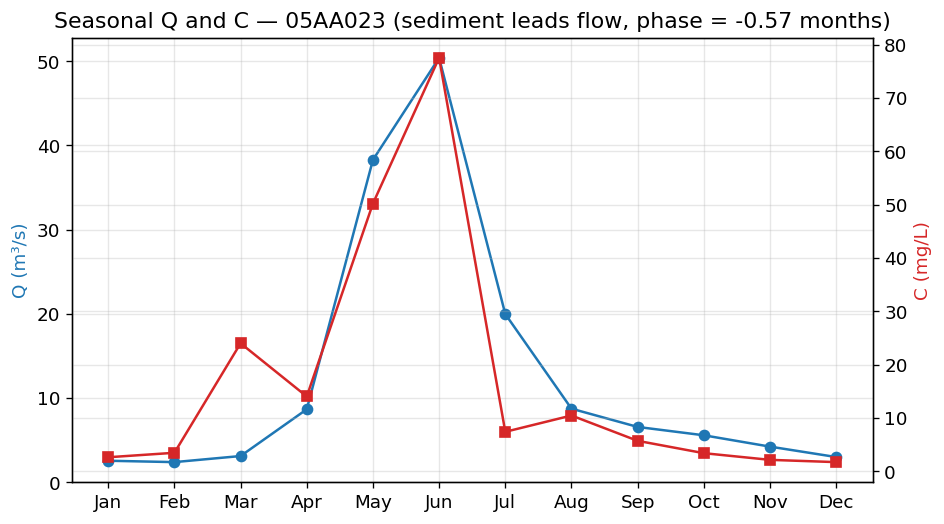


C–Q & SEASONAL HYSTERESIS — RUN SUMMARY
HYDAT version: [['1.0', '2026-04-17 08:16:30.000']]
Total stations: 8055 | regulated: 3127 | RHBN: 316
Latitude range: 42.03 to 81.79

-- DATA FUNNEL --
Paired suspended Q–C samples: 91,630 over 564 stations
Sample types before filtering: DI=84,302, PI=7,775, SV=35
Sample types retained:         DI=83,821, PI=7,774, SV=35
Rating curves fitted: 271 | significant (p<0.05): 253
Seasonal phase: 329 | closed loop: 183
Daily SUSCON years: 1948-1997, 5th-95th pct 1966-1989
Stations with D50: 380 | in primary set: 195
Within-station pre/post pairs: 1
==> Analysis subset: 271 | primary set: 253
    regime-classified: 223 | unclassified: 30
      incomplete annual cycle (<10 months): 24
      fewer than 5 years of monthly flow: 4
      no monthly-flow record: 2
    Mixed class in primary set: n=4, of which Sep/Oct peak=0
    PSD flow-percentile: median=65.2, mean=60.5, n=15,817, Wilcoxon p=0

-- REGIME CLASS COMPOSITION --
   Glacial / high-elevation   n=

In [4]:
# =============================================================================
# Canada-wide Suspended-Sediment Concentration-Discharge (C-Q) Behaviour and
# Seasonal Hysteresis across Cold-Region Flow Regimes
#
# Complete analysis pipeline for the accompanying manuscript. Running this file
# reproduces every table, figure, statistic and number reported in the paper.
#
#   python hydat_cq_pipeline.py
#
# Requirements: numpy, pandas, scipy, statsmodels, matplotlib.
# The HYDAT SQLite release is downloaded automatically from Environment and
# Climate Change Canada. If the archive is already present in the working
# directory it is reused.
#
# Implementation notes that are stated in the manuscript and visible below:
#   * Runoff depth is Q/A * 31536, which converts m3 s-1 km-2 to mm yr-1.
#     Runoff enters the regression only as log10(runoff), so the unit choice
#     affects the OLS intercept and nothing else.
#   * d50() enforces monotonicity of the cumulative percentage-finer curve
#     before interpolating, because np.interp requires a strictly increasing
#     abscissa and returns a wrong value, without warning, otherwise.
#   * chi2_contingency is called with correction=False.
#   * dsub_all retains stations without a regime; dsub does not. Table 1 is
#     computed over dsub, and both denominators are reported.
#   * Figure exemplars are the most densely sampled UNREGULATED station of each
#     class whose seasonal loop turns in the dominant sense of that class, and
#     the late-summer-peak panel is restricted to the Cordillera (BC/YT), where
#     glacier influence is plausible.
#   * The composition of every regime class is written to
#     regime_class_composition.csv and SUMMARY.txt, because the July-August
#     window also captures large rivers whose snowmelt freshet is delayed by
#     downstream routing and lake or reservoir storage.
#
# Outputs: hydat_cq_outputs/ (all CSVs, all figures, SUMMARY.txt) + a zip.
# =============================================================================

# Step 1: Download and extract the HYDAT database from the official archive.
import os, urllib.request, zipfile as _zipfile

HYDAT_URL = ("https://collaboration.cmc.ec.gc.ca/cmc/hydrometrics/www/"
             "Hydat_sqlite3_20260417.zip")
HYDAT_ZIP = "Hydat_sqlite3_20260417.zip"

if not os.path.exists(HYDAT_ZIP):
    print(f"[db] Downloading {HYDAT_URL}")
    urllib.request.urlretrieve(HYDAT_URL, HYDAT_ZIP)
with _zipfile.ZipFile(HYDAT_ZIP) as _zf:
    _zf.extractall(".")

# Step 2: Analysis, statistics, and figures.
import os, glob, sqlite3, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import fisher_exact, binomtest
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
np.random.seed(42)

# Tunable thresholds, kept together so every analysis choice is explicit.
CFG = dict(
    MIN_RATING_SAMPLES = 30,        # min paired Q–C samples to fit a station rating curve
    SENS_THRESHOLDS    = [50, 100], # extra sample thresholds for a sensitivity table
    N_BOOT             = 1000,      # bootstrap reps for the exponent b confidence interval
    MIN_PHASE_MONTHS   = 6,         # min calendar months to compute a C–Q seasonal phase
    MIN_LOOP_MONTHS    = 9,         # min calendar months to compute a closed-loop area
    MIN_FLOW_YEARS     = 5,         # min years of monthly flow for regime classification
    SEASONALITY_MIN    = 0.15,      # circular vector-strength below which a regime is "Mixed"
    FIT_PVAL           = 0.05,      # rating curves with slope p below this form the primary set
    OUTDIR             = "hydat_cq_outputs",
)
os.makedirs(CFG["OUTDIR"], exist_ok=True)
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"savefig.bbox":"tight",
                     "font.size":11,"axes.grid":True,"grid.alpha":0.3})

MONTHS = np.arange(1, 13)
MONTH_ABBR = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# ----------------------------- HELPERS ---------------------------------------
def find_database():
    """Return the path to the extracted HYDAT SQLite file."""
    sq = glob.glob("**/*.sqlite3", recursive=True)
    if sq:
        print(f"[db] Connected to database: {sq[0]}"); return sq[0]
    raise FileNotFoundError("[ERROR] No .sqlite3 file found (download/extract failed).")

def circ_month(months, weights):
    """Weighted circular-mean month (0–12). Treats the calendar as a circle so
    December and January are neighbours."""
    a = 2*np.pi*(np.asarray(months,float)-0.5)/12.0
    w = np.nan_to_num(np.asarray(weights,float))
    if w.sum() <= 0: return np.nan
    x,y = (w*np.cos(a)).sum(),(w*np.sin(a)).sum()
    return ((np.arctan2(y,x)%(2*np.pi))/(2*np.pi))*12.0

def vector_strength(months, weights):
    """Concentration of the seasonal cycle on the unit circle (0 = flat all year,
    1 = all mass in one month)."""
    a = 2*np.pi*(np.asarray(months,float)-0.5)/12.0
    w = np.nan_to_num(np.asarray(weights,float))
    if w.sum() <= 0: return np.nan
    x,y = (w*np.cos(a)).sum(),(w*np.sin(a)).sum()
    return np.hypot(x,y)/w.sum()

def loop_area_signed(q, c):
    """Signed area of the normalised monthly C–Q loop (shoelace formula)."""
    q=np.asarray(q,float); c=np.asarray(c,float)
    if len(q)<3 or q.max()==q.min() or c.max()==c.min(): return np.nan
    qn=(q-q.min())/(q.max()-q.min()); cn=(c-c.min())/(c.max()-c.min())
    x=np.append(qn,qn[0]); y=np.append(cn,cn[0])
    return 0.5*np.sum(x[:-1]*y[1:]-x[1:]*y[:-1])

def fit_loglog(q, c):
    """OLS on log10 C vs log10 Q. Returns slope b, intercept log10 a, R2, p, se."""
    lq,lc=np.log10(q),np.log10(c)
    r=stats.linregress(lq,lc)
    return r.slope, r.intercept, r.rvalue**2, r.pvalue, r.stderr

# =========================== STAGE 1–2: LOAD DB ==============================
DB = find_database()
con = sqlite3.connect(DB)
ver = pd.read_sql("SELECT * FROM VERSION", con)
print("HYDAT VERSION:", ver.values.tolist())

stations = pd.read_sql("""SELECT STATION_NUMBER, STATION_NAME, PROV_TERR_STATE_LOC AS PROV,
                                 LATITUDE, LONGITUDE, DRAINAGE_AREA_GROSS AS AREA, RHBN, HYD_STATUS
                          FROM STATIONS""", con)

reg = pd.read_sql("SELECT STATION_NUMBER, YEAR_FROM, REGULATED FROM STN_REGULATION", con)
ever_reg = set(reg.loc[reg.REGULATED == 1, "STATION_NUMBER"])
onset = (reg[reg.REGULATED == 1].groupby("STATION_NUMBER").YEAR_FROM.min()
         .rename("REG_ONSET").reset_index())
stations = stations.merge(onset, on="STATION_NUMBER", how="left")
stations["REGULATED"] = stations.STATION_NUMBER.isin(ever_reg).astype(int)

mf = pd.read_sql("""SELECT STATION_NUMBER, YEAR, MONTH, MONTHLY_MEAN AS Q
                    FROM DLY_FLOWS WHERE MONTHLY_MEAN IS NOT NULL AND FULL_MONTH = 1""", con)

# ===================== STAGE 3: FLOW REGIME CLASSIFICATION ====================
#   Apr–Jun  -> Nival   (spring snowmelt)
#   Jul–Aug  -> Glacial / high-elevation (late-summer melt)
#   Nov–Mar  -> Pluvial (rain-driven, cool-season)
# Sep–Oct straddle the melt recession and the onset of autumn rain and are not
# attributable to one runoff mechanism, so they fall to "Mixed", as do stations
# whose seasonal cycle is too flat to define a peak (low vector strength).
#
# NOTE: the labels name the mechanism a peak in each window most often implies,
# not a verified basin property. A July–August peak occurs in glacier-fed
# headwaters, but also in large rivers whose Cordilleran freshet is delayed by
# downstream routing and lake/reservoir storage. See the class-composition block.
yrs = mf.groupby("STATION_NUMBER").YEAR.nunique()
ok = yrs[yrs >= CFG["MIN_FLOW_YEARS"]].index
clim_flow = mf[mf.STATION_NUMBER.isin(ok)].groupby(["STATION_NUMBER","MONTH"]).Q.mean().reset_index()

reg_rows, clim_flow_pivot = [], {}
for stn, g in clim_flow.groupby("STATION_NUMBER"):
    g = g.sort_values("MONTH")
    if g.MONTH.nunique() < 10:          # require a near-complete annual cycle
        continue
    mo, qm = g.MONTH.values, g.Q.values
    full = np.full(12, np.nan); full[mo-1] = qm; clim_flow_pivot[stn] = full
    peak = int(mo[np.argmax(qm)]); R = vector_strength(mo, qm)

    low_seasonality = bool(R < CFG["SEASONALITY_MIN"])
    autumn_peak     = bool(peak in (9, 10))

    if   low_seasonality:       regime = "Mixed / weak seasonality"
    elif peak in (4,5,6):       regime = "Nival (snowmelt)"
    elif peak in (7,8):         regime = "Glacial / high-elevation"
    elif peak in (11,12,1,2,3): regime = "Pluvial (rain)"
    else:                       regime = "Mixed / weak seasonality"   # = Sep/Oct peak

    reg_rows.append(dict(STATION_NUMBER=stn, flow_peak_month=peak, flow_seasonality_R=R,
                         flow_centroid_month=circ_month(mo,qm), regime=regime,
                         low_seasonality=low_seasonality, autumn_peak=autumn_peak,
                         ann_mean_flow=np.nanmean(qm)))
regime_df = pd.DataFrame(reg_rows).merge(stations[["STATION_NUMBER","AREA"]], on="STATION_NUMBER", how="left")

# Mean annual runoff depth (Eq. 2 of the manuscript).
# Q [m3/s] / A [km2] = 1e-6 m/s; x 31.536e6 s/yr = 31.536 m/yr. The factor that
# gives millimetres per year is therefore 31,536.
#   Oldman R. nr Brocket: Q=36.7 m3/s, A=4407 km2 -> 262.6 mm/yr.
# Runoff enters the model only as log10(runoff), so the unit choice shifts the
# OLS intercept and leaves every slope, rank correlation and p-value unchanged.
regime_df["runoff_mm_yr"] = np.where(regime_df.AREA > 0,
                                     regime_df.ann_mean_flow/regime_df.AREA*31536.0, np.nan)

_mx = regime_df[regime_df.regime == "Mixed / weak seasonality"]
print(f"[regime] Mixed class n={len(_mx)}  (aseasonal R<{CFG['SEASONALITY_MIN']}: "
      f"{int(_mx.low_seasonality.sum())}; Sep/Oct peak: "
      f"{int((_mx.autumn_peak & ~_mx.low_seasonality).sum())})")

# ============== STAGE 4: RATING CURVES (instantaneous Q–C) ===================
ss = pd.read_sql("""SELECT STATION_NUMBER, DATE, SED_DATA_TYPE, FLOW, CONCENTRATION
                    FROM SED_SAMPLES WHERE FLOW IS NOT NULL AND CONCENTRATION IS NOT NULL""", con)
sed_types_raw = ss.SED_DATA_TYPE.value_counts()
print("\nSED_SAMPLES by type:"); print(sed_types_raw)
ss = ss[~ss.SED_DATA_TYPE.isin(["BL","BM"])]
ss = ss[(ss.FLOW>0)&(ss.CONCENTRATION>0)].copy()
ss["year"] = pd.to_datetime(ss.DATE, errors="coerce").dt.year
sed_types_kept = ss.SED_DATA_TYPE.value_counts()

def fit_station(g, n_boot):
    q,c = g.FLOW.values, g.CONCENTRATION.values
    b,loga,r2,p,se = fit_loglog(q,c)
    lq,lc = np.log10(q),np.log10(c); n=len(q); boot=np.empty(n_boot)
    for i in range(n_boot):                       # resample samples with replacement
        while True:
            idx=np.random.randint(0,n,n)
            if lq[idx].max()!=lq[idx].min():      # skip degenerate resamples
                boot[i]=stats.linregress(lq[idx],lc[idx]).slope; break
    lo,hi=np.percentile(boot,[2.5,97.5]); resid=lc-(b*lq+loga)
    return dict(n_samples=n,b=b,b_se=se,b_ci_lo=lo,b_ci_hi=hi,a_log10=loga,a=10**loga,
                r2=r2,p_value=p,logC_resid_sd=np.std(resid),median_logQ=np.median(lq))

rows=[]
for stn,g in ss.groupby("STATION_NUMBER"):
    if len(g)<CFG["MIN_RATING_SAMPLES"] or g.FLOW.max()==g.FLOW.min(): continue
    r=fit_station(g,CFG["N_BOOT"]); r["STATION_NUMBER"]=stn; rows.append(r)
rating=pd.DataFrame(rows)
rating["fit_ok"]=(rating.p_value<CFG["FIT_PVAL"]).astype(int)
print(f"\nRating curves: {len(rating)} stations (significant: {int(rating.fit_ok.sum())})")

sens_rows=[dict(threshold=CFG["MIN_RATING_SAMPLES"],n_stations=len(rating),median_b=rating.b.median())]
for thr in CFG["SENS_THRESHOLDS"]:
    sub=rating[rating.n_samples>=thr]
    sens_rows.append(dict(threshold=thr,n_stations=len(sub),median_b=sub.b.median()))
sens_df=pd.DataFrame(sens_rows)

# =============== STAGE 5: SEASONAL HYSTERESIS (monthly C–Q loop) ==============
sus = pd.read_sql("SELECT * FROM SED_DLY_SUSCON", con)
val = [f"SUSCON{i}" for i in range(1,32)]
susm = sus.melt(id_vars=["STATION_NUMBER","YEAR","MONTH"], value_vars=val, value_name="C").dropna(subset=["C"])
susm = susm[susm.C>0]
monthly_C = susm.groupby(["STATION_NUMBER","YEAR","MONTH"]).C.mean().rename("C").reset_index()
clim_C = monthly_C.groupby(["STATION_NUMBER","MONTH"]).C.mean().reset_index()
clim_Q = mf.groupby(["STATION_NUMBER","MONTH"]).Q.mean().reset_index()
merged = clim_C.merge(clim_Q, on=["STATION_NUMBER","MONTH"], how="inner")

loop_rows, loop_store = [], {}
for stn,g in merged.groupby("STATION_NUMBER"):
    g=g.sort_values("MONTH"); nmo=g.MONTH.nunique()
    if nmo<CFG["MIN_PHASE_MONTHS"]: continue
    mo,qm,cm=g.MONTH.values,g.Q.values,g.C.values; loop_store[stn]=(mo,qm,cm)
    phase=((circ_month(mo,cm)-circ_month(mo,qm)+6)%12)-6     # wrap to [-6, +6] months
    area=loop_area_signed(qm,cm) if nmo>=CFG["MIN_LOOP_MONTHS"] else np.nan
    loop_rows.append(dict(STATION_NUMBER=stn,n_loop_months=nmo,
                          C_peak_month=int(mo[np.argmax(cm)]),Q_peak_month=int(mo[np.argmax(qm)]),
                          phase_C_minus_Q=phase,loop_area_signed=area,
                          hyst_dir=("clockwise/flushing" if phase<0 else "counter-clockwise")))
loop_station=pd.DataFrame(loop_rows)
print(f"Seasonal phase: {loop_station.phase_C_minus_Q.notna().sum()} stations; "
      f"closed loop: {loop_station.loop_area_signed.notna().sum()}")
suscon_years = (int(susm.YEAR.min()), int(susm.YEAR.max()),
                int(susm.YEAR.quantile(.05)), int(susm.YEAR.quantile(.95)))

# ============ STAGE 6: REGULATION (cross-sectional + optional pre/post) ======
baci_rows=[]
reg_ss = ss.merge(stations[["STATION_NUMBER","REG_ONSET","REGULATED"]], on="STATION_NUMBER", how="left")
for stn,g in reg_ss[(reg_ss.REGULATED==1) & reg_ss.REG_ONSET.notna()].groupby("STATION_NUMBER"):
    oy=g.REG_ONSET.iloc[0]; pre=g[g.year<oy]; post=g[g.year>=oy]
    if len(pre)>=CFG["MIN_RATING_SAMPLES"] and len(post)>=CFG["MIN_RATING_SAMPLES"]:
        b0,la0,*_=fit_loglog(pre.FLOW.values,pre.CONCENTRATION.values)
        b1,la1,*_=fit_loglog(post.FLOW.values,post.CONCENTRATION.values)
        baci_rows.append(dict(STATION_NUMBER=stn,onset=int(oy),n_pre=len(pre),n_post=len(post),
                              b_pre=b0,b_post=b1,db=b1-b0,a_pre=10**la0,a_post=10**la1,dlog_a=la1-la0))
baci=pd.DataFrame(baci_rows)
print(f"\nWithin-station pre/post pairs: {len(baci)}")

# ============ STAGE 7: PARTICLE SIZE (median suspended D50) ==================
psd = pd.read_sql("""SELECT STATION_NUMBER, DATE, PARTICLE_SIZE, PERCENT
                     FROM SED_SAMPLES_PSD WHERE SED_DATA_TYPE IN ('DI','PI') AND PARTICLE_SIZE>0""", con)

def d50(g):
    """Median grain size of one suspended particle-size sample.

    The percentage-finer curve is cumulative and cannot decrease with increasing
    grain size; small decreases are measurement noise. np.interp requires its xp
    array to be strictly increasing and returns a wrong value, without warning,
    if it is not. Enforce monotonicity with a running maximum, discarding no
    sample, then interpolate on the strictly increasing points.
    """
    g = g.sort_values("PARTICLE_SIZE")
    y = g.PARTICLE_SIZE.values
    x = np.maximum.accumulate(g.PERCENT.values)
    keep = np.concatenate(([True], np.diff(x) > 0))
    x, y = x[keep], y[keep]
    if len(x) < 2 or not (x.min() <= 50 <= x.max()):
        return np.nan
    return float(np.interp(50, x, y))

station_d50 = (psd.groupby(["STATION_NUMBER","DATE"])[["PARTICLE_SIZE","PERCENT"]]
                  .apply(d50).dropna()
                  .groupby("STATION_NUMBER").median().rename("D50_mm").reset_index())
print(f"Stations with D50: {len(station_d50)}")

# Is particle-size sampling biased toward high flow? Match each PSD sample to the
# discharge measured the same day at the same station, and locate that discharge
# within the station's own sampled-flow distribution.
psd_bias = {}
try:
    j = (psd[["STATION_NUMBER","DATE"]].drop_duplicates()
         .merge(ss[["STATION_NUMBER","DATE","FLOW"]].drop_duplicates(),
                on=["STATION_NUMBER","DATE"], how="inner"))
    pct = []
    for stn, g in j.groupby("STATION_NUMBER"):
        allq = ss.loc[ss.STATION_NUMBER == stn, "FLOW"].values
        if len(allq) < 10: continue
        pct.extend(100*np.searchsorted(np.sort(allq), g.FLOW.values)/len(allq))
    pct = np.asarray(pct)
    if len(pct) >= 30:
        _, wp = stats.wilcoxon(pct - 50)
        psd_bias = dict(n=len(pct), median_pctile=float(np.median(pct)),
                        mean_pctile=float(np.mean(pct)), wilcoxon_p=float(wp))
        print(f"[psd] flow percentile of PSD samples: median={np.median(pct):.1f} "
              f"(50 = no bias), n={len(pct):,}, Wilcoxon p={wp:.3g}")
except Exception as e:
    print("[psd] bias test skipped:", e)
con.close()

# ===================== STAGE 8: MASTER TABLE + STATISTICS ====================
master = (stations.merge(rating,on="STATION_NUMBER",how="left")
                  .merge(regime_df.drop(columns=["AREA"]),on="STATION_NUMBER",how="left")
                  .merge(loop_station,on="STATION_NUMBER",how="left")
                  .merge(station_d50,on="STATION_NUMBER",how="left"))
master["has_rating"]=master.b.notna()
analysis = master[master.has_rating].copy()
quality  = analysis[analysis.fit_ok==1].copy()
print(f"\n==> Analysis subset: {len(analysis)} | primary (significant fits): {len(quality)}")

# Why do some primary-set stations carry no regime? They are absent from
# regime_df, hence dropped silently by groupby('regime') and by the regression.
_mons = clim_flow.groupby("STATION_NUMBER").MONTH.nunique()
unclassified = quality[quality.regime.isna()].copy()
unclassified["n_flow_years"]  = unclassified.STATION_NUMBER.map(yrs).fillna(0).astype(int)
unclassified["n_flow_months"] = unclassified.STATION_NUMBER.map(_mons).fillna(0).astype(int)
unclassified["reason"] = np.select(
    [unclassified.n_flow_years == 0,
     unclassified.n_flow_years <  CFG["MIN_FLOW_YEARS"],
     unclassified.n_flow_months < 10],
    ["no monthly-flow record",
     f"fewer than {CFG['MIN_FLOW_YEARS']} years of monthly flow",
     "incomplete annual cycle (<10 months)"], default="other")
print(f"[regime] classified: {int(quality.regime.notna().sum())} | unclassified: {len(unclassified)}")
print(unclassified.reason.value_counts().to_string())

# Class composition. The peak-month rule labels the mechanism that a peak most
# often implies, not a verified basin property, so what each class actually
# contains is reported explicitly (Sections 4.2 and 5.4 of the manuscript).
comp_rows = []
for rg in ["Glacial / high-elevation","Nival (snowmelt)","Pluvial (rain)","Mixed / weak seasonality"]:
    s = quality[quality.regime == rg]
    if not len(s): continue
    comp_rows.append(dict(regime=rg, n=len(s),
                          median_area_km2=s.AREA.median(),
                          n_area_gt_50000=int((s.AREA > 5e4).sum()),
                          n_cordillera_BC_YT=int(s.PROV.isin(["BC","YT"]).sum()),
                          n_prairie_boreal_AB_SK_MB=int(s.PROV.isin(["AB","SK","MB"]).sum()),
                          n_ontario=int((s.PROV == "ON").sum()),
                          n_regulated=int(s.REGULATED.sum()),
                          median_runoff_mm_yr=s.runoff_mm_yr.median()))
class_comp = pd.DataFrame(comp_rows)
print("\n[class composition]"); print(class_comp.round(1).to_string(index=False))

glacial_members = (quality[quality.regime == "Glacial / high-elevation"]
                   [["STATION_NUMBER","STATION_NAME","PROV","AREA","REGULATED","b"]]
                   .sort_values("AREA", ascending=False))
print("\n[late-summer-peak class, all members by drainage area]")
print(glacial_members.to_string(index=False))

# Kruskal-Wallis across all four regime classes -> dof = k - 1 = 3.
def kruskal_by(df,v):
    grps=[g[v].dropna().values for _,g in df.groupby("regime") if g[v].notna().sum()>=3]
    if len(grps)<2: return np.nan,np.nan,np.nan,0
    H,p = stats.kruskal(*grps)
    return H,p,len(grps)-1,len(grps)

stat_lines=[]
Hb,pb,dfb,kb = kruskal_by(quality,"b")
stat_lines.append(f"KW b~regime: H={Hb:.2f}, dof={dfb} (k={kb} classes), p={pb:.3g}")
Hp,pp,dfp,kp = kruskal_by(quality.dropna(subset=['phase_C_minus_Q']),"phase_C_minus_Q")
stat_lines.append(f"KW phase~regime: H={Hp:.2f}, dof={dfp} (k={kp} classes), p={pp:.3g}")

# Hysteresis direction as a categorical outcome.
# dsub_all keeps regime==NaN; dsub does not. The regime rows of Table 1 describe
# dsub. Reporting a percentage over dsub_all alongside them mixes denominators.
dsub_all = quality.dropna(subset=["phase_C_minus_Q"]).copy()
dsub_all["cw"] = (dsub_all.phase_C_minus_Q < 0).astype(int)
dsub = dsub_all[dsub_all.regime.notna()].copy()

main3 = dsub[dsub.regime.isin(["Nival (snowmelt)","Pluvial (rain)","Glacial / high-elevation"])]
dir_tab = pd.crosstab(main3.regime, main3.cw)
chi2, chip, chidof, _ = stats.chi2_contingency(dir_tab, correction=False)  # Yates inert at dof=2
stat_lines.append(f"Chi-square hysteresis direction ~ regime: chi2={chi2:.2f}, dof={chidof}, p={chip:.3g}")

# The chi-square rests mainly on the two well-populated classes. Check it alone,
# free of any sparse-cell concern from the 13 glacial stations.
def _cnt(rg):
    s = main3[main3.regime==rg]; return int(s.cw.sum()), int(len(s)-s.cw.sum())
nv, pl, gl = _cnt("Nival (snowmelt)"), _cnt("Pluvial (rain)"), _cnt("Glacial / high-elevation")
fisher_or, fisher_p = fisher_exact([list(nv), list(pl)])
stat_lines.append(f"Fisher exact (nival vs pluvial): OR={fisher_or:.2f}, p={fisher_p:.3g}")

ci_rows=[]
for rg,g in dsub.groupby("regime"):
    k,n = int(g.cw.sum()), len(g)
    ci = binomtest(k,n).proportion_ci(confidence_level=0.95, method="exact")
    ci_rows.append(dict(regime=rg,n_phase=n,n_clockwise=k,pct_clockwise=100*k/n,
                        ci_lo=100*ci.low,ci_hi=100*ci.high))
k,n = int(dsub.cw.sum()), len(dsub)
ci = binomtest(k,n).proportion_ci(confidence_level=0.95, method="exact")
ci_rows.append(dict(regime="All (regime-classified)",n_phase=n,n_clockwise=k,
                    pct_clockwise=100*k/n,ci_lo=100*ci.low,ci_hi=100*ci.high))
k,n = int(dsub_all.cw.sum()), len(dsub_all)
ci_rows.append(dict(regime="All (incl. unclassified)",n_phase=n,n_clockwise=k,
                    pct_clockwise=100*k/n,ci_lo=np.nan,ci_hi=np.nan))
hyst_ci = pd.DataFrame(ci_rows)
print("\n[hysteresis] direction with exact 95% CI:"); print(hyst_ci.round(1).to_string(index=False))

# Cross-sectional regulated vs unregulated comparison on each headline metric.
def mwu(df,v):
    x=df[df.REGULATED==1][v].dropna(); y=df[df.REGULATED==0][v].dropna()
    if len(x)<5 or len(y)<5: return None
    U,p=stats.mannwhitneyu(x,y,alternative="two-sided")
    return dict(metric=v,n_reg=len(x),n_nat=len(y),median_reg=x.median(),median_nat=y.median(),U=U,p=p)
mwu_df=pd.DataFrame([r for r in (mwu(quality,v) for v in ["b","a","phase_C_minus_Q","loop_area_signed"]) if r])

# Multiple regression: partial effect of each driver on b and on phase.
def run_ols(df,dep):
    d=df.dropna(subset=[dep,"AREA","LATITUDE","runoff_mm_yr","regime","REGULATED"]).copy()
    d=d[(d.AREA>0)&(d.runoff_mm_yr>0)]
    if len(d)<25: return None,None
    d["log_area"]=np.log10(d.AREA); d["log_runoff"]=np.log10(d.runoff_mm_yr)
    m=smf.ols(f"{dep} ~ C(regime)+log_area+LATITUDE+log_runoff+REGULATED",data=d).fit()
    c=(pd.DataFrame({"coef":m.params,"se":m.bse,"t":m.tvalues,"p":m.pvalues})
       .reset_index().rename(columns={"index":"term"}))
    c["dep"]=dep; c["r2"]=m.rsquared; c["n"]=int(m.nobs); return m,c
m_b,coef_b   = run_ols(quality,"b")
m_ph,coef_ph = run_ols(quality.dropna(subset=["phase_C_minus_Q"]),"phase_C_minus_Q")
coef_all=pd.concat([c for c in [coef_b,coef_ph] if c is not None],ignore_index=True)

# Rank correlations of b and phase with continuous drivers, including grain size.
def spear(df,x,y):
    d=df[[x,y]].dropna()
    if len(d)<8: return None
    rho,p=stats.spearmanr(d[x],d[y]); return dict(x=x,y=y,n=len(d),spearman_rho=rho,p=p)
corr_df=pd.DataFrame([r for y in ["b","phase_C_minus_Q"]
                        for x in ["LATITUDE","AREA","runoff_mm_yr","D50_mm","flow_centroid_month"]
                        for r in [spear(quality,x,y)] if r])

# Runoff depth is collinear with regime, so its marginal and partial effects on b
# can differ in sign. Record both; the interpretation depends on it.
_d = quality[["runoff_mm_yr","b"]].dropna()
_rho,_pr = stats.spearmanr(_d.runoff_mm_yr,_d.b)
_row = coef_b.loc[coef_b.term=="log_runoff"]
_c,_cp = float(_row.coef.iloc[0]), float(_row.p.iloc[0])
stat_lines.append(f"Runoff depth -> b: MARGINAL Spearman rho={_rho:+.3f} (p={_pr:.3g}, n={len(_d)})")
stat_lines.append(f"Runoff depth -> b: PARTIAL OLS coef={_c:+.3f} per log10 unit (p={_cp:.3g})")
stat_lines.append(f"  -> signs {'DIFFER (collinearity reversal)' if _rho*_c<0 else 'agree'}")

# Compact summaries. n_phase and n_d50 are the denominators Table 1 needs.
def iqr(s): return s.quantile(.75)-s.quantile(.25)
regime_summary=(quality.groupby("regime").agg(
    n=("b","count"), b_median=("b","median"), b_iqr=("b",iqr), a_median=("a","median"),
    n_phase=("phase_C_minus_Q","count"), phase_median=("phase_C_minus_Q","median"),
    pct_clockwise=("phase_C_minus_Q",lambda s:100*np.mean(s.dropna()<0) if s.notna().sum() else np.nan),
    n_d50=("D50_mm","count"), D50_median_mm=("D50_mm","median")).reset_index())
region_summary=(quality.groupby("PROV").agg(n=("b","count"),b_median=("b","median"),
                 phase_median=("phase_C_minus_Q","median")).reset_index().sort_values("n",ascending=False))
print("\n[Table 1 source]"); print(regime_summary.round(3).to_string(index=False))

# ----------------------------- SAVE TABLES ----------------------------------
def save(df,name): df.to_csv(os.path.join(CFG["OUTDIR"],name),index=False)
save(master,"master_table.csv"); save(analysis,"analysis_subset.csv")
save(quality,"analysis_primary.csv"); save(rating,"rating_curve_params.csv")
save(loop_station,"hysteresis_results.csv"); save(baci,"regulation_prepost.csv")
save(mwu_df,"regulated_vs_unregulated_tests.csv"); save(coef_all,"regression_coefficients.csv")
save(corr_df,"spearman_correlations.csv"); save(regime_summary,"summary_by_regime.csv")
save(region_summary,"summary_by_province.csv"); save(sens_df,"rating_threshold_sensitivity.csv")
save(hyst_ci,"hysteresis_direction_ci.csv")
save(class_comp,"regime_class_composition.csv")
save(glacial_members,"late_summer_peak_class_members.csv")
save(unclassified[["STATION_NUMBER","STATION_NAME","PROV","n_flow_years","n_flow_months","reason"]],
     "unclassified_stations.csv")
dir_tab.to_csv(os.path.join(CFG["OUTDIR"],"hysteresis_direction_by_regime.csv")); save(ver,"hydat_version.csv")

# ============================ STAGE 9: FIGURES ==============================
def savefig(name):
    plt.tight_layout(); plt.savefig(os.path.join(CFG["OUTDIR"],name)); plt.show(); plt.close()
pal={"Nival (snowmelt)":"#1f77b4","Glacial / high-elevation":"#17becf",
     "Pluvial (rain)":"#2ca02c","Mixed / weak seasonality":"#999999"}
A=quality   # figures use the primary set

try:  # geographic map of stations coloured by flow regime
    plt.figure(figsize=(9,6))
    for rg,c in pal.items():
        s=A[A.regime==rg]; plt.scatter(s.LONGITUDE,s.LATITUDE,s=22,c=c,label=rg,edgecolor="k",linewidth=.2,alpha=.85)
    plt.xlabel("Longitude");plt.ylabel("Latitude");plt.title("Sediment stations by flow regime")
    plt.gca().set_aspect(1.6);plt.legend(fontsize=8,loc="lower left");savefig("fig01_map_regime.png")
except Exception as e: print("fig1:",e)

try:  # map coloured by the rating-curve exponent b
    plt.figure(figsize=(9,6))
    sc=plt.scatter(A.LONGITUDE,A.LATITUDE,c=A.b,s=26,cmap="viridis",edgecolor="k",linewidth=.2)
    plt.colorbar(sc,label="rating-curve exponent b");plt.xlabel("Longitude");plt.ylabel("Latitude")
    plt.title("Spatial pattern of the C–Q exponent b");plt.gca().set_aspect(1.6);savefig("fig02_map_b.png")
except Exception as e: print("fig2:",e)

try:  # distribution of b across regimes
    order=[r for r in pal if (A.regime==r).sum()>0]
    plt.figure(figsize=(8,5))
    bp=plt.boxplot([A[A.regime==r].b.dropna() for r in order],tick_labels=[r.split(" (")[0] for r in order],showmeans=True,patch_artist=True)
    for p_,r in zip(bp["boxes"],order): p_.set_facecolor(pal[r]); p_.set_alpha(.6)
    plt.ylabel("rating-curve exponent b");plt.title("C–Q exponent by flow regime");plt.xticks(rotation=15);savefig("fig03_b_by_regime.png")
except Exception as e: print("fig3:",e)

try:  # share of clockwise vs counter-clockwise loops by regime
    order=["Glacial / high-elevation","Nival (snowmelt)","Pluvial (rain)"]
    cw=[main3[main3.regime==r].cw.mean()*100 for r in order]; ccw=[100-x for x in cw]
    plt.figure(figsize=(7,4.8))
    plt.bar(range(3),cw,color="#1f77b4",label="Clockwise / flushing (C leads Q)")
    plt.bar(range(3),ccw,bottom=cw,color="#d9a441",label="Counter-clockwise (C lags Q)")
    plt.xticks(range(3),[r.split(" (")[0] for r in order]);plt.ylabel("% of stations")
    for i,c in enumerate(cw):
        plt.text(i,c/2,f"{c:.0f}%",ha="center",color="white",fontweight="bold")
        plt.text(i,101,f"n={(main3.regime==order[i]).sum()}",ha="center",fontsize=9)
    plt.axhline(50,color="k",lw=1,ls="--");plt.legend(loc="lower center",fontsize=9,framealpha=.9)
    plt.title(f"Hysteresis direction by regime (chi2={chi2:.1f}, p={chip:.1g})");savefig("fig04_hysteresis_direction.png")
except Exception as e: print("fig4:",e)

try:  # b against latitude and against basin size
    fig,ax=plt.subplots(1,2,figsize=(12,5))
    ax[0].scatter(A.LATITUDE,A.b,s=20,alpha=.7);ax[0].set_xlabel("Latitude");ax[0].set_ylabel("b");ax[0].set_title("b vs latitude")
    ax[1].scatter(np.log10(A.AREA),A.b,s=20,alpha=.7);ax[1].set_xlabel("log10 area (km²)");ax[1].set_ylabel("b");ax[1].set_title("b vs basin size")
    plt.suptitle("Drivers of the C–Q exponent");savefig("fig05_b_drivers.png")
except Exception as e: print("fig5:",e)

# Figure exemplars. Within each class the most densely sampled UNREGULATED
# station is selected, subject to two constraints.
#   (i) The station must carry a seasonal phase whose rotational sense is the
#       dominant one of its own class: clockwise (phase < 0) for the nival and
#       late-summer-peak classes, counter-clockwise (phase > 0) for the pluvial
#       class. Without this constraint the panels can illustrate the minority
#       behaviour of their class, which is the opposite of what the figure is
#       for. Sampling density alone does not select a typical loop.
#  (ii) The late-summer-peak panel is further restricted to the Cordillera
#       (BC/YT), where glacier influence is plausible.
# Unregulated stations only, so that the seasonal signal is not confounded with
# impoundment effects.
fig06_picks_log = []
try:  # representative monthly C–Q loops, one per regime
    picks=[]
    _spec={"Nival (snowmelt)":         (-1, None),          # expect clockwise
           "Pluvial (rain)":           (+1, None),          # expect counter-clockwise
           "Glacial / high-elevation": (-1, ["BC","YT"])}   # expect clockwise, Cordillera
    for rg,(sense,provs) in _spec.items():
        cand=A[(A.regime==rg)&(A.REGULATED==0)&(A.STATION_NUMBER.isin(loop_store))
               &(A.phase_C_minus_Q.notna())]
        if provs is not None: cand=cand[cand.PROV.isin(provs)]
        cand=cand[np.sign(cand.phase_C_minus_Q)==sense]
        if not len(cand):                       # fall back rather than drop a panel
            cand=A[(A.regime==rg)&(A.STATION_NUMBER.isin(loop_store))]
        if len(cand): picks.append((rg,cand.sort_values("n_samples",ascending=False).STATION_NUMBER.iloc[0]))
    for rg,stn in picks:
        r=stations.loc[stations.STATION_NUMBER==stn].iloc[0]
        _ph=float(A.loc[A.STATION_NUMBER==stn,"phase_C_minus_Q"].iloc[0])
        fig06_picks_log.append(f"{rg:26s} {stn}  {str(r.STATION_NAME)[:40]:42s} {r.PROV}  "
                               f"area={r.AREA:.2f} km2  regulated={int(r.REGULATED)}  "
                               f"phase={_ph:+.2f} ({'clockwise' if _ph<0 else 'counter-clockwise'})")
    print("\n[fig06 exemplars]"); [print("  "+x) for x in fig06_picks_log]
    if picks:
        fig,axes=plt.subplots(1,len(picks),figsize=(4.4*len(picks),4.2));axes=np.atleast_1d(axes)
        for ax,(lab,stn) in zip(axes,picks):
            mo,qm,cm=loop_store[stn];ax.plot(qm,cm,"-o",color="#444")
            for x,y,mm in zip(qm,cm,mo): ax.annotate(MONTH_ABBR[mm-1],(x,y),fontsize=7)
            nm=stations.loc[stations.STATION_NUMBER==stn,"STATION_NAME"].iloc[0][:22]
            ax.set_title(f"{lab}\n{stn} {nm}",fontsize=9);ax.set_xlabel("Q (m³/s)");ax.set_ylabel("C (mg/L)")
        plt.suptitle("Representative monthly C–Q seasonal loops");savefig("fig06_example_loops.png")
except Exception as e: print("fig6:",e)

try:  # regulated vs unregulated rivers
    fig,ax=plt.subplots(1,3,figsize=(13,4.5))
    for a_,v,t in zip(ax,["b","a","phase_C_minus_Q"],["exponent b","coefficient a","phase (C−Q)"]):
        dn=A[A.REGULATED==0][v].dropna();dr=A[A.REGULATED==1][v].dropna()
        a_.boxplot([dn,dr],tick_labels=["Unregulated","Regulated"],showmeans=True);a_.set_title(t)
        if v=="a": a_.set_yscale("log")
    plt.suptitle("Regulated vs unregulated rivers");savefig("fig07_regulated_vs_unregulated.png")
except Exception as e: print("fig7:",e)

try:  # mean seasonal flow archetype per regime (normalised Pardé curves)
    plt.figure(figsize=(8,5))
    for rg,c in pal.items():
        sub=[clim_flow_pivot[s] for s in A[A.regime==rg].STATION_NUMBER if s in clim_flow_pivot]
        if not sub: continue
        arr=np.vstack(sub); arr=arr/np.nanmean(arr,axis=1,keepdims=True)
        plt.plot(MONTHS,np.nanmean(arr,axis=0),"-o",color=c,label=rg.split(" (")[0])
    plt.xticks(MONTHS,MONTH_ABBR);plt.ylabel("Pardé coefficient");plt.title("Mean seasonal flow regime by class");plt.legend(fontsize=8);savefig("fig08_regime_archetypes.png")
except Exception as e: print("fig8:",e)

try:  # histogram of the exponent b
    plt.figure(figsize=(7,4.5))
    plt.hist(A.b.dropna(),bins=30,color="#4477aa",edgecolor="k",alpha=.8)
    plt.axvline(A.b.median(),color="red",ls="--",label=f"median = {A.b.median():.2f}")
    plt.xlabel("rating-curve exponent b");plt.ylabel("stations");plt.title("Distribution of the C–Q exponent");plt.legend();savefig("fig09_b_hist.png")
except Exception as e: print("fig9:",e)

try:  # b versus grain size D50
    d=A[["D50_mm","b"]].dropna()
    if len(d)>=8:
        plt.figure(figsize=(7,4.5));plt.scatter(d.D50_mm,d.b,s=24,alpha=.8);plt.xscale("log")
        rho,p=stats.spearmanr(d.D50_mm,d.b)
        plt.xlabel("median suspended D50 (mm)");plt.ylabel("b")
        plt.title(f"C–Q exponent vs grain size (ρ={rho:.2f}, p={p:.2g}, n={len(d)})");savefig("fig10_b_vs_d50.png")
except Exception as e: print("fig10:",e)

fig11_stn = None
try:  # dual-axis seasonal Q and C for a snowmelt river, showing the lead/lag
    # Same constraint as fig06: a clockwise station, so that the panel shows the
    # concentration lead the caption claims. The title is derived from the phase
    # rather than asserted.
    cand=A[(A.regime=="Nival (snowmelt)")&(A.REGULATED==0)&(A.STATION_NUMBER.isin(loop_store))
           &(A.phase_C_minus_Q<0)]
    if not len(cand): cand=A[(A.regime=="Nival (snowmelt)")&(A.STATION_NUMBER.isin(loop_store))]
    if len(cand):
        stn=cand.sort_values("n_samples",ascending=False).STATION_NUMBER.iloc[0]; fig11_stn=stn
        mo,qm,cm=loop_store[stn]
        ph=float(A.loc[A.STATION_NUMBER==stn,"phase_C_minus_Q"].iloc[0])
        lead = "sediment leads flow" if ph < 0 else "sediment lags flow"
        fig,ax1=plt.subplots(figsize=(8,4.5));ax2=ax1.twinx()
        ax1.plot(mo,qm,"-o",color="#1f77b4");ax2.plot(mo,cm,"-s",color="#d62728")
        ax1.set_xticks(MONTHS);ax1.set_xticklabels(MONTH_ABBR)
        ax1.set_ylabel("Q (m³/s)",color="#1f77b4");ax2.set_ylabel("C (mg/L)",color="#d62728")
        ax1.set_title(f"Seasonal Q and C — {stn} ({lead}, phase = {ph:+.2f} months)")
        savefig("fig11_seasonal_QC.png")
except Exception as e: print("fig11:",e)

# ============================== RUN SUMMARY =================================
def fmt(x,d=2):
    try: return f"{x:.{d}f}"
    except: return "NA"
S=[]
S.append("="*78); S.append("C–Q & SEASONAL HYSTERESIS — RUN SUMMARY"); S.append("="*78)
S.append(f"HYDAT version: {ver.values.tolist()}")
S.append(f"Total stations: {len(stations)} | regulated: {int(stations.REGULATED.sum())} | RHBN: {int(stations.RHBN.fillna(0).sum())}")
S.append(f"Latitude range: {stations.LATITUDE.min():.2f} to {stations.LATITUDE.max():.2f}")
S.append("")
S.append("-- DATA FUNNEL --")
S.append(f"Paired suspended Q–C samples: {len(ss):,} over {ss.STATION_NUMBER.nunique()} stations")
S.append("Sample types before filtering: " + ", ".join(f"{k}={v:,}" for k,v in sed_types_raw.items()))
S.append("Sample types retained:         " + ", ".join(f"{k}={v:,}" for k,v in sed_types_kept.items()))
S.append(f"Rating curves fitted: {len(rating)} | significant (p<{CFG['FIT_PVAL']}): {int(rating.fit_ok.sum())}")
S.append(f"Seasonal phase: {loop_station.phase_C_minus_Q.notna().sum()} | closed loop: {loop_station.loop_area_signed.notna().sum()}")
S.append(f"Daily SUSCON years: {suscon_years[0]}-{suscon_years[1]}, 5th-95th pct {suscon_years[2]}-{suscon_years[3]}")
S.append(f"Stations with D50: {len(station_d50)} | in primary set: {int(quality.D50_mm.notna().sum())}")
S.append(f"Within-station pre/post pairs: {len(baci)}")
S.append(f"==> Analysis subset: {len(analysis)} | primary set: {len(quality)}")
S.append(f"    regime-classified: {int(quality.regime.notna().sum())} | unclassified: {len(unclassified)}")
for k,v in unclassified.reason.value_counts().items(): S.append(f"      {k}: {v}")
_mxq = quality[quality.regime=="Mixed / weak seasonality"]
S.append(f"    Mixed class in primary set: n={len(_mxq)}, of which Sep/Oct peak={int(_mxq.autumn_peak.sum())}")
if psd_bias:
    S.append(f"    PSD flow-percentile: median={psd_bias['median_pctile']:.1f}, mean={psd_bias['mean_pctile']:.1f}, "
             f"n={psd_bias['n']:,}, Wilcoxon p={psd_bias['wilcoxon_p']:.3g}")
S.append("")
S.append("-- REGIME CLASS COMPOSITION --")
for _,r in class_comp.iterrows():
    S.append(f"   {r.regime:26s} n={int(r.n):3d}  med.area={r.median_area_km2:9.0f} km2  "
             f">50k km2={int(r.n_area_gt_50000):2d}  BC/YT={int(r.n_cordillera_BC_YT):2d}  "
             f"AB/SK/MB={int(r.n_prairie_boreal_AB_SK_MB):2d}  ON={int(r.n_ontario):2d}  "
             f"reg={int(r.n_regulated):2d}  med.runoff={r.median_runoff_mm_yr:6.0f} mm/yr")
S.append("")
S.append("-- FIGURE EXEMPLARS (unregulated; class-dominant loop sense; late-summer = BC/YT) --")
for x in fig06_picks_log: S.append("   fig06 "+x)
S.append(f"   fig11 nival station: {fig11_stn}")
S.append("")
S.append("-- RATING-CURVE EXPONENT b (primary set) --")
S.append(f"median b={fmt(quality.b.median())}, IQR [{fmt(quality.b.quantile(.25))},{fmt(quality.b.quantile(.75))}], median R²={fmt(quality.r2.median())}")
S.append("Threshold sensitivity (all fits, no significance filter): "+" | ".join(f">={int(r.threshold)}:n={int(r.n_stations)},b={fmt(r.median_b)}" for _,r in sens_df.iterrows()))
S.append("")
S.append("-- BY REGIME --")
for _,r in regime_summary.iterrows():
    S.append(f"   {r.regime:26s} n={int(r.n):3d} b={fmt(r.b_median)} IQR={fmt(r.b_iqr)} a={fmt(r.a_median)} "
             f"| n_phi={int(r.n_phase):3d} cw={fmt(r.pct_clockwise,0)}% phase={fmt(r.phase_median)} "
             f"| n_d50={int(r.n_d50):3d} D50={fmt(r.D50_median_mm,3)}")
S.append("")
S.append("-- HYSTERESIS DIRECTION, WITH EXACT 95% CI --")
for _,r in hyst_ci.iterrows():
    ci = "" if np.isnan(r.ci_lo) else f"  CI [{r.ci_lo:.0f}, {r.ci_hi:.0f}]"
    S.append(f"   {r.regime:28s} n_phi={int(r.n_phase):3d}  cw={int(r.n_clockwise):3d} ({r.pct_clockwise:.1f}%){ci}")
S.append("")
S.append("-- STATISTICAL TESTS --")
S += ["   "+s for s in stat_lines]
if len(mwu_df):
    S.append("   Regulated vs unregulated (Mann–Whitney):")
    for _,r in mwu_df.iterrows():
        S.append(f"      {r.metric:16s} med_reg={fmt(r.median_reg)} med_nat={fmt(r.median_nat)} p={r.p:.3g} (n_reg={int(r.n_reg)},n_nat={int(r.n_nat)})")
if len(baci):
    S.append(f"   Within-station Δb median={fmt(baci.db.median())} (n={len(baci)})")
    for _,r in baci.iterrows():
        S.append(f"      {r.STATION_NUMBER} onset={int(r.onset)} n_pre={int(r.n_pre)} n_post={int(r.n_post)} "
                 f"b {r.b_pre:.2f}->{r.b_post:.2f}  a {r.a_pre:.2f}->{r.a_post:.2f}")
for _m,_lab,_c in [(m_b,"b",coef_b),(m_ph,"phase",coef_ph)]:
    if _m is None: continue
    S.append(f"   OLS {_lab}~drivers: R²={fmt(_m.rsquared)}, n={int(_m.nobs)}, F-p={_m.f_pvalue:.3g}")
    for _,r in _c.iterrows():
        S.append(f"      {r.term:34s} coef={r.coef:+.4f} se={r.se:.4f} p={r.p:.3g}")
if len(corr_df):
    S.append("   Spearman (driver → b / phase):")
    for _,r in corr_df.iterrows():
        S.append(f"      {r.x:20s} → {r.y:16s} ρ={fmt(r.spearman_rho)} p={r.p:.3g} (n={int(r.n)})")
S.append("="*78)
txt="\n".join(S); print("\n"+txt)
open(os.path.join(CFG["OUTDIR"],"SUMMARY.txt"),"w").write(txt)

# ------------------------------- ZIP OUTPUTS --------------------------------
zp="hydat_cq_outputs.zip"
with zipfile.ZipFile(zp,"w",zipfile.ZIP_DEFLATED) as zf:
    for fn in sorted(os.listdir(CFG["OUTDIR"])): zf.write(os.path.join(CFG["OUTDIR"],fn),arcname=fn)
print(f"\nWritten to '{CFG['OUTDIR']}/' and zipped to '{zp}'.")
print("\nDONE.")
